Processing 8 files in output_00005
 12% : read     317136 cells
 25% : read     591432 cells
 37% : read     901120 cells
 50% : read    1226768 cells
 62% : read    1632440 cells
 75% : read    1910985 cells
 87% : read    2203705 cells
Total number of cells loaded: 2528548
Total particles loaded: 2106925
density 0.0001
pressure 0.0001
temperature 0.0001
metallicity 0.0001
PASSED


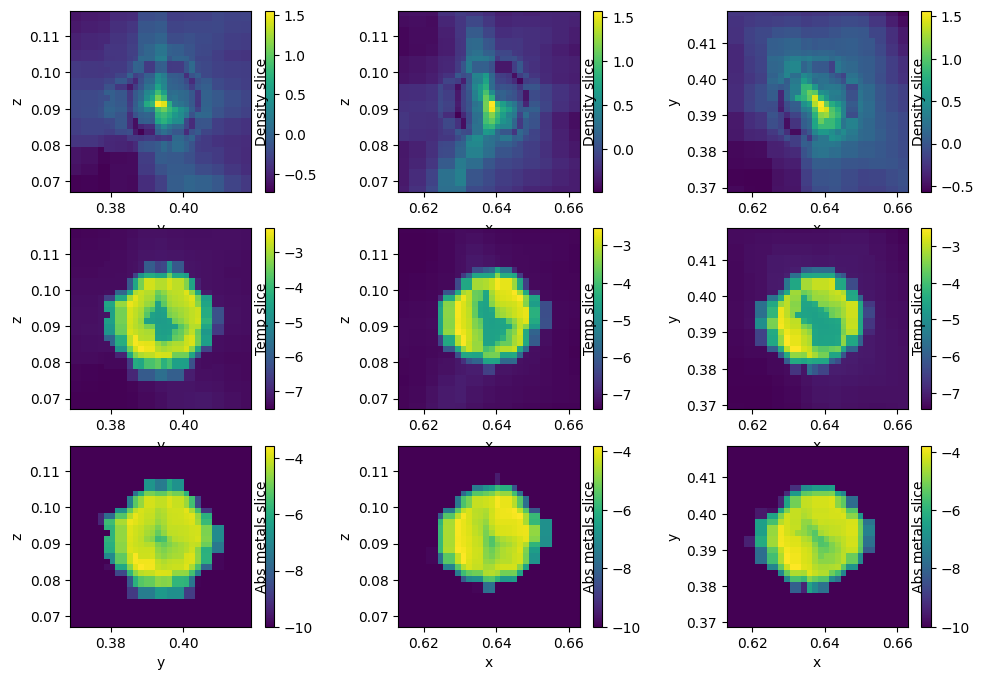

In [9]:
import matplotlib as mpl
import numpy as np
from scipy.interpolate import griddata
# uncomment for command line use, comment for notebook
#mpl.use("Agg")
import matplotlib.pyplot as plt
import visu_ramses
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))

# Load RAMSES output
data = visu_ramses.load_snapshot(5,read_hydro=True)
xp = data["particle"]["position_x"]
yp = data["particle"]["position_y"]
zp = data["particle"]["position_z"]
mp = data["particle"]["mass"]
x      = data["data"]["x"]
y      = data["data"]["y"]
z      = data["data"]["z"]
dx     = data["data"]["dx"]
rho    = data["data"]["density"]
p      = data["data"]["pressure"]
l      = data["data"]["level"]
metals = data["data"]["metallicity"]

temp=p/rho
# find highest density cell
itmax=np.argmax(rho)
xtmax=x[itmax]
ytmax=y[itmax]
ztmax=z[itmax]

zoomdx=0.025

xmin = np.max([(xtmax-zoomdx),0.])
xmax = np.min([(xtmax+zoomdx),1.])
ymin = np.max([(ytmax-zoomdx),0.])
ymax = np.min([(ytmax+zoomdx),1.])
zmin = np.max([(ztmax-zoomdx),0.])
zmax = np.min([(ztmax+zoomdx),1.])

# make a subcube of half-size zoomdx around max rho
nx  = 2**5
dpx = (xmax-xmin)/float(nx)
dpy = (ymax-ymin)/float(nx)
dpz = (zmax-zmin)/float(nx)
xpx = np.linspace(xmin+0.5*dpx,xmax-0.5*dpx,nx)
ypx = np.linspace(ymin+0.5*dpy,ymax-0.5*dpy,nx)
zpx = np.linspace(zmin+0.5*dpz,zmax-0.5*dpz,nx)
grid_x, grid_y, grid_z = np.meshgrid(xpx,ypx,zpx)
points = np.transpose([x,y,z])
z1 = griddata(points,rho,(grid_x,grid_y, grid_z),method='nearest')
z5 = griddata(points,p,(grid_x,grid_y, grid_z),method='nearest')
zl = griddata(points,l,(grid_x,grid_y, grid_z),method='nearest')
Z = griddata(points,metals,(grid_x,grid_y, grid_z),method='nearest')

temp=z5/z1

rho_proj2=z1[:,int(nx/2.),:]
rho_proj1=z1[int(nx/2.),:,:]
rho_proj3=z1[:,:,int(nx/2.)]

Z_proj2=Z[:,int(nx/2.),:]
Z_proj1=Z[int(nx/2.),:,:]
Z_proj3=Z[:,:,int(nx/2.)]



T_proj2=temp[:,int(nx/2.),:]
T_proj1=temp[int(nx/2.),:,:]
T_proj3=temp[:,:,int(nx/2.)]

T_tot2=np.mean(temp,axis=1)
T_tot1=np.mean(temp,axis=0)
T_tot3=np.mean(temp,axis=2)

rho_tot2=np.mean(z1,axis=1)
rho_tot1=np.mean(z1,axis=0)
rho_tot3=np.mean(z1,axis=2)


im1 = ax[0,0].imshow(np.log10(rho_proj1), origin="lower", aspect='equal', extent=[ymin, ymax, zmin, zmax],interpolation='none')
im2 = ax[0,1].imshow(np.log10(rho_proj2), origin="lower", aspect='equal', extent=[xmin, xmax, zmin, zmax],interpolation='none')
im3 = ax[0,2].imshow(np.log10(rho_proj3), origin="lower", aspect='equal', extent=[xmin, xmax, ymin, ymax],interpolation='none')
im4 = ax[1,0].imshow(np.log10(T_proj1), origin="lower", aspect='equal', extent=[ymin, ymax, zmin, zmax],interpolation='none')
im5 = ax[1,1].imshow(np.log10(T_proj2), origin="lower", aspect='equal', extent=[xmin, xmax, zmin, zmax],interpolation='none')
im6 = ax[1,2].imshow(np.log10(T_proj3), origin="lower", aspect='equal', extent=[xmin, xmax, ymin, ymax],interpolation='none')
im7 = ax[2,0].imshow(np.log10(Z_proj1+1.e-10), origin="lower", aspect='equal', extent=[ymin, ymax, zmin, zmax],interpolation='none')
im8 = ax[2,1].imshow(np.log10(Z_proj2+1.e-10), origin="lower", aspect='equal', extent=[xmin, xmax, zmin, zmax],interpolation='none')
im9 = ax[2,2].imshow(np.log10(Z_proj3+1.e-10), origin="lower", aspect='equal', extent=[xmin, xmax, ymin, ymax],interpolation='none')


cb = []
cb.append(plt.colorbar(im1, ax=ax[0,0], label='Density slice'))
cb.append(plt.colorbar(im2, ax=ax[0,1], label='Density slice'))
cb.append(plt.colorbar(im3, ax=ax[0,2], label='Density slice'))
cb.append(plt.colorbar(im4, ax=ax[1,0], label='Temp slice'))
cb.append(plt.colorbar(im5, ax=ax[1,1], label='Temp slice'))
cb.append(plt.colorbar(im6, ax=ax[1,2], label='Temp slice'))
cb.append(plt.colorbar(im7, ax=ax[2,0], label='Abs metals slice'))
cb.append(plt.colorbar(im8, ax=ax[2,1], label='Abs metals slice'))
cb.append(plt.colorbar(im9, ax=ax[2,2], label='Abs metals slice'))

for i in [0,1,2]:
    ax[i,0].set_xlabel('y')
    ax[i,0].set_ylabel('z')
    ax[i,1].set_xlabel('x')
    ax[i,1].set_ylabel('z')
    ax[i,2].set_xlabel('x')
    ax[i,2].set_ylabel('y')


for c in cb:
    c.ax.yaxis.set_label_coords(-1.1, 0.5)

fig.savefig('SNFB.pdf',bbox_inches='tight')
fig.savefig('SNFB.png') # => sometimes produces a less blurry figure

to_check={}
to_check["pressure"]=z5.flatten()  # data["data"]["pressure"]
to_check["density"]=z1.flatten()
to_check["temperature"]=temp.flatten()
to_check["metallicity"]=Z.flatten() 


# tweak tolerance to allow for 2p vs 4p and 8p deviations:
tolerance={"density":1.0e-4,\
           "pressure":1.e-4,\
           "temperature":1.e-4,\
           "metallicity":1.e-4,\
          }

visu_ramses.check_solution(to_check, 'SNFB',tolerance=tolerance)#,overwrite=True)




In [25]:
tolerance["particle"]

KeyError: 'particle'

In [21]:
temp_4p=np.copy(temp)

In [19]:
temp_8p=temp

In [27]:
tdiff=temp_4p-temp_8p
reltdiff=tdiff/temp_4p


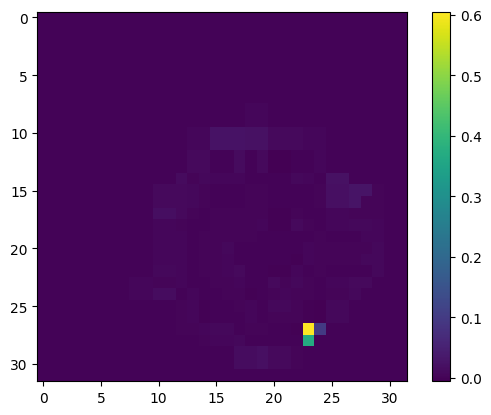

In [30]:
plt.imshow(reltdiff[int(nx/2),:,:])
plt.colorbar()